# Step 5 — 태그 효과 LR 통합 (Track2 / Phase 2)

- **목적**: 태그 **내용**(FDR 생존 7개)이 `tag_cnt`(개수) 너머 `log_views` 신호를 더하는지 다변량 LR로 검증
- **모델**: pooled **M0**(obj feats + tag_cnt + C(hour_bin)+C(publish_weekday)+C(category)) vs **M_tags**(M0 + 태그 7개 이진)
- **평가**: statsmodels OLS(계수·p) + sklearn 5-fold CV R²(±std) + rand-split test R² + test-set permutation importance
- **누수 차단**: 업로드시점 변수만. trending_lag/참여지표 제외
- **FDR-7**: Film(disney+, movie+, trailer+) · Music(pop+, country−, music−, alternative−)
- **정직성**: 감성 ΔR≈−0.002 전례 → R² 급등 기대 X. 태그는 전체 데이터 유의성으로 사후선택됨(double-dipping) → CV/test 중심 해석

In [1]:
import numpy as np, pandas as pd
import statsmodels.api as sm
from scipy.stats import skew
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

RS = 42
FEAT = "../../../Analysis1_title/LR/features_partB_v2.csv"
TAGS = "../phase1/step1_tags_parsed.csv"
FDR7 = ["disney","movie","trailer","pop","country","music","alternative"]
TAG_COLS = [f"is_{t}" for t in FDR7]
NUM_OBJ = ["title_len","caps_ratio","exclaim_cnt","question_cnt","has_number","has_bracket","tag_cnt"]
PRIMARY, ACCENT, GRAY = "#3B4FE4", "#1A7F5A", "#C8CDD6"
print("config OK")

config OK


In [2]:
# 로드 + 머지 (video_id 기준, features 기준 left join)
feat = pd.read_csv(FEAT)
tags = pd.read_csv(TAGS)
df = feat.merge(tags[["video_id","tags_joined"]], on="video_id", how="left")
matched = df["tags_joined"].notna().sum()
print(f"feat={feat.shape} tags={tags.shape} merged={df.shape}")
print(f"tags matched={matched}  no_tag(NaN)={len(df)-matched} ({(len(df)-matched)/len(df)*100:.1f}%)")
assert df["video_id"].is_unique, "video_id not unique after merge"

feat=(6249, 18) tags=(6249, 4) merged=(6249, 19)
tags matched=6005  no_tag(NaN)=244 (3.9%)


In [3]:
# FDR-7 태그 이진 feature 생성 (tags_joined 토큰 set 멤버십)
def tokset(s):
    if pd.isna(s): return set()
    return {t for t in str(s).split("|") if t}
tok = df["tags_joined"].map(tokset)
for t in FDR7:
    df[f"is_{t}"] = tok.map(lambda ts, t=t: int(t in ts))
prev = {c:int(df[c].sum()) for c in TAG_COLS}
print("태그 prevalence (전체 n):", prev)

태그 prevalence (전체 n): {'is_disney': 65, 'is_movie': 138, 'is_trailer': 214, 'is_pop': 191, 'is_country': 46, 'is_music': 262, 'is_alternative': 49}


In [4]:
# 왜도 체크 (보고용; 해석성 위해 선형 유지)
sk = {c: round(float(skew(df[c].astype(float))),3) for c in ["title_len","exclaim_cnt","question_cnt","tag_cnt"]}
cands = [c for c,v in sk.items() if abs(v)>0.75]
print("skew(count feats):", sk)
print("log1p 후보(|skew|>0.75):", cands)
print("결정: 계수 해석성(H4 서사) 우선 → 헤드라인 모델은 선형 유지. (로그변환은 추후 robustness로만)")

skew(count feats): {'title_len': 0.443, 'exclaim_cnt': 4.021, 'question_cnt': 4.46, 'tag_cnt': 0.323}
log1p 후보(|skew|>0.75): ['exclaim_cnt', 'question_cnt']
결정: 계수 해석성(H4 서사) 우선 → 헤드라인 모델은 선형 유지. (로그변환은 추후 robustness로만)


In [5]:
# 디자인 행렬 (get_dummies drop_first → sm/sklearn 동일 컬럼)
catv = df[["hour_bin","publish_weekday","category"]].astype(str)
dummies = pd.get_dummies(catv, drop_first=True).astype(float)
X0 = pd.concat([df[NUM_OBJ].astype(float), dummies], axis=1)
Xt = pd.concat([X0, df[TAG_COLS].astype(float)], axis=1)
y = df["log_views"].astype(float)
print(f"M0 design: {X0.shape}  |  M_tags design: {Xt.shape}")
print(f"추가된 태그 컬럼 {len(TAG_COLS)}개:", TAG_COLS)

M0 design: (6249, 31)  |  M_tags design: (6249, 38)
추가된 태그 컬럼 7개: ['is_disney', 'is_movie', 'is_trailer', 'is_pop', 'is_country', 'is_music', 'is_alternative']


In [6]:
# statsmodels OLS — 계수·p (다변량, 통제 후)
ols0 = sm.OLS(y, sm.add_constant(X0)).fit()
olst = sm.OLS(y, sm.add_constant(Xt)).fit()
print(f"[in-sample] M0     R²={ols0.rsquared:.4f}  adjR²={ols0.rsquared_adj:.4f}")
print(f"[in-sample] M_tags R²={olst.rsquared:.4f}  adjR²={olst.rsquared_adj:.4f}")
ctab = pd.DataFrame({"coef":olst.params,"std_err":olst.bse,"p":olst.pvalues}).loc[TAG_COLS]
ctab["sig"] = np.where(ctab["p"]<0.05,"*","")
ctab["mult_exp"] = np.exp(ctab["coef"]).round(3)
ctab = ctab.round({"coef":4,"std_err":4,"p":4})
print("\n[M_tags 태그 계수]")
print(ctab)
ctab.to_csv("step5_tag_coefs.csv")
print("saved -> step5_tag_coefs.csv")

[in-sample] M0     R²=0.1213  adjR²=0.1169
[in-sample] M_tags R²=0.1280  adjR²=0.1227

[M_tags 태그 계수]
                  coef  std_err       p sig  mult_exp
is_disney       0.3121   0.2156  0.1478         1.366
is_movie        0.0058   0.1547  0.9699         1.006
is_trailer      0.1249   0.1321  0.3446         1.133
is_pop          0.3428   0.1378  0.0129   *     1.409
is_country     -0.8024   0.2587  0.0019   *     0.448
is_music       -0.4876   0.1129  0.0000   *     0.614
is_alternative -0.8474   0.2533  0.0008   *     0.429
saved -> step5_tag_coefs.csv


In [7]:
# 단일 rand split test R² (compare_sentiment M0 vs M1 미러링)
Xtr0,Xte0,ytr,yte = train_test_split(X0,y,test_size=0.2,random_state=RS)
Xtrt,Xtet,_,_ = train_test_split(Xt,y,test_size=0.2,random_state=RS)
r2_0 = LinearRegression().fit(Xtr0,ytr).score(Xte0,yte)
m_t = LinearRegression().fit(Xtrt,ytr); r2_t = m_t.score(Xtet,yte)
print(f"[rand split test R²] M0={r2_0:.4f}  M_tags={r2_t:.4f}  ΔR²={r2_t-r2_0:+.4f}")

[rand split test R²] M0=0.1188  M_tags=0.1210  ΔR²=+0.0023


In [8]:
# 5-fold CV R² + 비교표 저장
kf = KFold(n_splits=5, shuffle=True, random_state=RS)
cv0 = cross_val_score(LinearRegression(), X0, y, cv=kf, scoring="r2")
cvt = cross_val_score(LinearRegression(), Xt, y, cv=kf, scoring="r2")
print(f"[5-fold CV R²] M0     ={cv0.mean():.4f}±{cv0.std():.4f}")
print(f"[5-fold CV R²] M_tags ={cvt.mean():.4f}±{cvt.std():.4f}")
print(f"ΔR²(CV mean)={cvt.mean()-cv0.mean():+.4f}  (0이 ±std 안이면 무의미)")
comp = pd.DataFrame({
    "model":["M0","M_tags"],
    "n_features":[X0.shape[1],Xt.shape[1]],
    "insample_r2":[ols0.rsquared,olst.rsquared],
    "cv_r2_mean":[cv0.mean(),cvt.mean()],
    "cv_r2_std":[cv0.std(),cvt.std()],
    "rand_test_r2":[r2_0,r2_t],
}).round(4)
comp.loc[comp["model"]=="M_tags","delta_cv_mean"]=round(cvt.mean()-cv0.mean(),4)
comp.loc[comp["model"]=="M_tags","delta_rand_test"]=round(r2_t-r2_0,4)
comp.to_csv("step5_model_compare_tags.csv", index=False)
print(comp)
print("saved -> step5_model_compare_tags.csv")

[5-fold CV R²] M0     =0.1067±0.0168
[5-fold CV R²] M_tags =0.1109±0.0194
ΔR²(CV mean)=+0.0042  (0이 ±std 안이면 무의미)
    model  n_features  insample_r2  cv_r2_mean  cv_r2_std  rand_test_r2  \
0      M0          31       0.1213      0.1067     0.0168        0.1188   
1  M_tags          38       0.1280      0.1109     0.0194        0.1210   

   delta_cv_mean  delta_rand_test  
0            NaN              NaN  
1         0.0042           0.0023  
saved -> step5_model_compare_tags.csv


[test-set permutation importance — 태그 7개]
is_disney        -0.00070
is_trailer       -0.00004
is_movie          0.00006
is_alternative    0.00024
is_pop            0.00134
is_country        0.00258
is_music          0.00802
dtype: float64


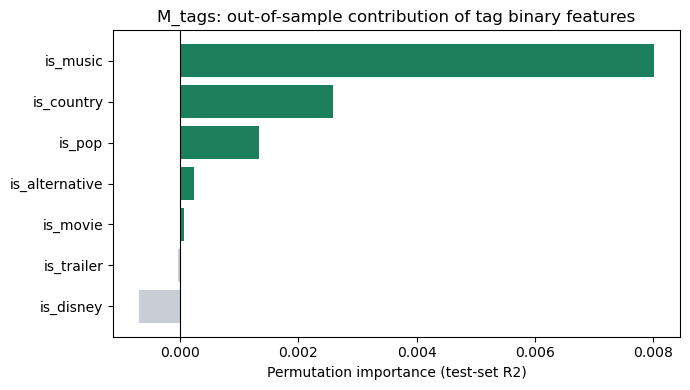

saved -> step5_fig_perm_importance.png


In [9]:
# test-set permutation importance (M_tags) + 시각화
pi = permutation_importance(m_t, Xtet, yte, n_repeats=30, random_state=RS, scoring="r2")
pis = pd.Series(pi.importances_mean, index=Xt.columns)
tag_pi = pis.loc[TAG_COLS].sort_values()
print("[test-set permutation importance — 태그 7개]")
print(tag_pi.round(5))
fig, ax = plt.subplots(figsize=(7,4))
colors = [ACCENT if v>0 else GRAY for v in tag_pi.values]
ax.barh(tag_pi.index, tag_pi.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Permutation importance (test-set R2)")
ax.set_title("M_tags: out-of-sample contribution of tag binary features")
plt.tight_layout()
plt.savefig("step5_fig_perm_importance.png", dpi=200)
plt.show()
print("saved -> step5_fig_perm_importance.png")

## 해석 메모 (실행 후 채울 것)

- **ΔR² (CV mean ± std)**: __ → 0이 std 안인지 = 태그 내용이 개수 너머 **예측력**을 더하는가
- **다변량 태그 계수**(`step5_tag_coefs.csv`): 단변량(Step 3) 부호/유의성이 통제 후에도 유지되는가
- **permutation importance**: 표본 밖에서 실제 기여 태그
- **정직성**: 태그 사후선택(double-dipping) → 낙관 편향 가능, CV/test 수치로 보고. 메타데이터 천장 낮음 서사 유지. temporal drift(time-split)는 별개 finding.
- **결론 한 줄**: tag_cnt 너머 내용 신호 (유/무 + 한계)